## Creating a Artificial Neural Network(ANN) / Mutli-Level Perceptron (MLP)

# Fashion-MNIST Dataset

### About Dataset
## Context

**Fashion-MNIST** is a dataset of Zalando's article images consisting of:
- **Training set:** 60,000 examples
- **Test set:** 10,000 examples
- **Image format:** 28×28 grayscale images
- **Labels:** 10 clothing classes

Fashion-MNIST serves as a direct drop-in replacement for the original MNIST dataset for benchmarking machine learning algorithms. It shares the same image size and structure of training and testing splits.

### Why Fashion-MNIST?

The original MNIST dataset contains handwritten digits and has become a staple in the AI/ML/Data Science community as a benchmark for validating algorithms. However, researchers recognized a limitation: "If it doesn't work on MNIST, it won't work at all"—but conversely, "if it does work on MNIST, it may still fail on others." Zalando created Fashion-MNIST to provide a more realistic and challenging alternative.

## Content

### Image Structure

- **Dimensions:** 28 pixels (height) × 28 pixels (width)
- **Total pixels:** 784
- **Pixel values:** Integer between 0 and 255 (higher = darker)

### Data Format

Each dataset file contains 785 columns:
- **Column 1:** Class label (0–9)
- **Columns 2–785:** Pixel values (784 total)

### Pixel Location

To locate a pixel on the image, decompose pixel index `x` as:

```
x = i * 28 + j
```

where `i` and `j` are integers between 0 and 27.

The pixel is located at **row i, column j** of the 28×28 matrix.

**Example:** Pixel 31 is located at the **4th column from the left, 2nd row from the top**.

## Labels

| Label | Class |
|-------|-------|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

## TL;DR

- Each row represents a separate image
- Column 1 is the class label
- Remaining 784 columns are pixel values
- Each pixel value ranges from 0–255 (darkness level)

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [24]:
# set random seed for reproducibility
torch.manual_seed(39482)

In [25]:
df = pd.read_csv(r"D:\Codes\Artificial_Intelligence\Deep_Learning\PyTorch\datasets\fashion_mnist\fashion-mnist_train.csv")

In [26]:
df.head(32)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,4,0,0,0,5,4,5,5,3,5,...,7,8,7,4,3,7,5,0,0,0
6,4,0,0,0,0,0,0,0,0,0,...,14,0,0,0,0,0,0,0,0,0
7,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,4,0,0,0,0,0,0,3,2,0,...,1,0,0,0,0,0,0,0,0,0
9,8,0,0,0,0,0,0,0,0,0,...,203,214,166,0,0,0,0,0,0,0


In [27]:
df.shape

(60000, 785)

In [28]:
28*28

784

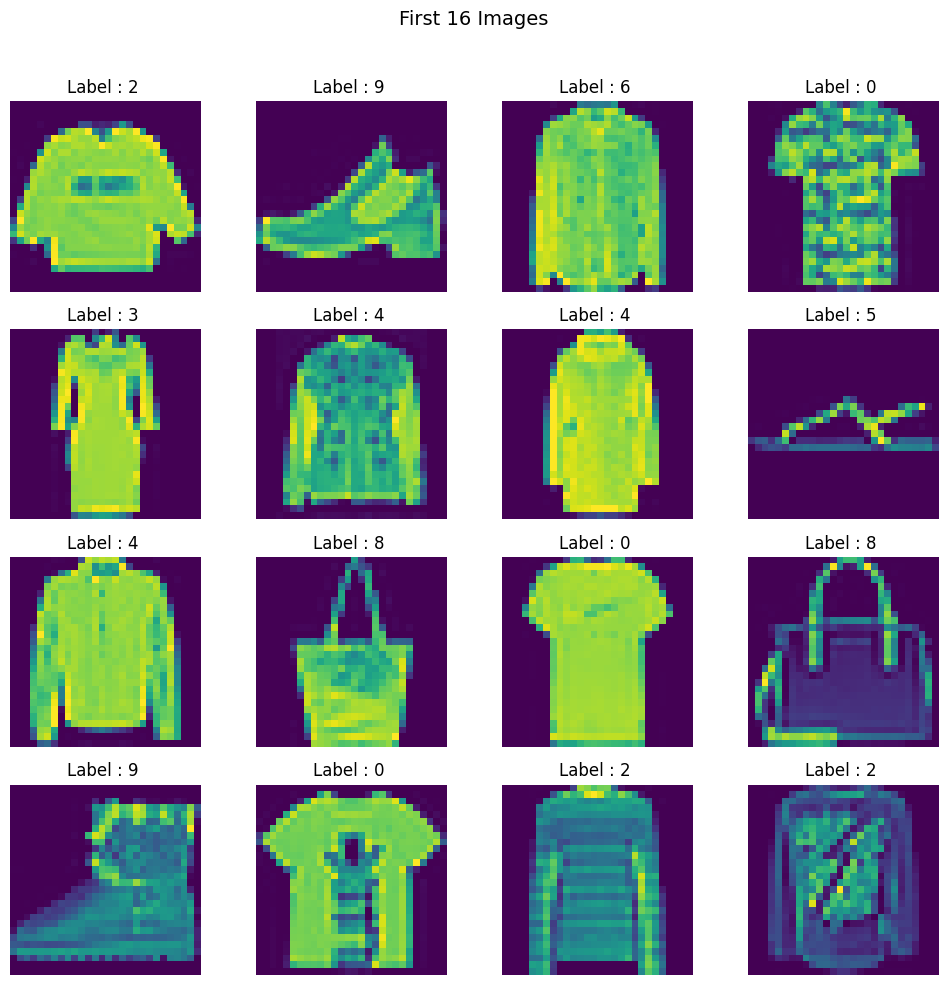

In [29]:
# create 4x4 grid of images
fig, axes = plt.subplots(4,4, figsize=(10, 10))
fig.suptitle('First 16 Images', fontsize=14)
# plot the first 16  images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28) # reshape to 28X28
    ax.imshow(img) # display in grayscale
    ax.axis('off')
    ax.set_title(f'Label : {df.iloc[i, 0]} ') # show the label

plt.tight_layout(rect=[0, 0, 1, 0.96]) # adjust layout to fit the title
plt.show()

#### train test split

In [30]:
x = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [31]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2)

In [32]:
X_train.shape, X_test.shape

((48000, 784), (12000, 784))

### scaling the features between 0-1

maximum value in any row is 255 so we are dividing each row values by 255.0 to make so that it will scale between 0-1

In [33]:
X_train = X_train/255.0
X_test = X_test/255.0

In [34]:
X_train.shape

(48000, 784)

### Create CustomDataset Class

In [35]:
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.from_numpy(features).to(torch.float32)
        self.labels = torch.from_numpy(labels).to(torch.long)

    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


In [36]:
# create train and test dataset ojects
train_dataset = CustomDataset(X_train, Y_train)
test_dataset = CustomDataset(X_test, Y_test)

In [37]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0039,
         0.0000, 0.4667, 0.8588, 0.6549, 0.6157, 0.5882, 0.5373, 0.5412, 0.4980,
         0.6118, 0.0902, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0039, 0.0000, 0.5647, 0.8980, 0.8549, 0.8392, 0.8706, 0.7373, 0.7529,
         0.6627, 0.8196, 0.2627, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.6784, 0.8353, 0.7255, 0.7608, 0.8549, 0.6667,
         0.7216, 0.6353, 0.7725, 0.2588, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.9608, 0.8157, 0.7882, 0.7569, 0.8314,
         0.6667, 0.6980, 0.6706, 0.7608, 0.3059, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

### Create train and test DataLoader objects

In [44]:
train_loader = DataLoader(train_dataset, batch_size=20, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=20, shuffle=False) # we are not shuffling the test dataset because it using shuffle will trouble in getting a clear loss

## Define Neural Network with 1 Hidden layers 

input size(784) -> layer 1 (relu)(size=128) -> hidden layer 2 (relu)(size=64) -> output layer(softmax)(size = 10)

In [45]:
class MyNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
            #nn.Softmax()        ## here we don't need to add the Softmax() activation because when we find the cross_entropy_loss it applies the Softmax by default
        )
        
    def forward(self, x):
        return self.model(x)

In [53]:
# important parameters
epochs = 100
learning_rate = 0.05

#### Calling the model

In [54]:
# initiate the model
model = MyNN(X_train.shape[1])

# loss function 
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

### Training Loop

In [55]:
# total number of batches
len(train_loader)

2400

In [56]:
for epoch in range(epochs):
    
    total_epoch_loss = 0

    for batch_features, batch_labels in train_loader:
        
        #forward pass
        y_pred = model(batch_features)
        
        # calculate loss
        loss = criterion(y_pred, batch_labels)
        
        # backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # update grads
        optimizer.step()

        total_epoch_loss = total_epoch_loss + loss.item()
        
    average_loss = total_epoch_loss/len(train_loader)
    
    print(f'Epoch: {epoch+1} | Average Loss = {average_loss}')

Epoch: 1 | Average Loss = 0.6513310227512071
Epoch: 2 | Average Loss = 0.4362437313562259
Epoch: 3 | Average Loss = 0.3903209251460309
Epoch: 4 | Average Loss = 0.36344074334949256
Epoch: 5 | Average Loss = 0.3424253658251837
Epoch: 6 | Average Loss = 0.32578209658308577
Epoch: 7 | Average Loss = 0.3140854966555101
Epoch: 8 | Average Loss = 0.29887747585928687
Epoch: 9 | Average Loss = 0.2906248883328711
Epoch: 10 | Average Loss = 0.2793426720099524
Epoch: 11 | Average Loss = 0.2711443299350018
Epoch: 12 | Average Loss = 0.26393978171943067
Epoch: 13 | Average Loss = 0.256218421581046
Epoch: 14 | Average Loss = 0.24805493182502686
Epoch: 15 | Average Loss = 0.2410227567423135
Epoch: 16 | Average Loss = 0.2344122586721399
Epoch: 17 | Average Loss = 0.2299928062785572
Epoch: 18 | Average Loss = 0.22322310605163997
Epoch: 19 | Average Loss = 0.21883984911527174
Epoch: 20 | Average Loss = 0.21428447968074277
Epoch: 21 | Average Loss = 0.2102251897463187
Epoch: 22 | Average Loss = 0.2044628

### Evaluating the Model

**Note:** The output will be a tensor of size (20, 10) where 20 is the size of the batch and the 10 as output size of what we have added in the starting in creating the nerual network

Each 10 values of each row which corresponds to the probability of the each label. We pick the maximum probability will be that will coresponds to a label.

In [ ]:
model.eval()

total = 0
correct = 0
  
with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        output = model(batch_features)
        _, predicted = torch.max(output, 1) # torch.max(values, indices) # return the maximum value and its index

        total += batch_labels.shape[0]

        correct = correct + (predicted == batch_labels).sum().item()
        
print(correct/total)

0.8905
